In [16]:
!pip install deap numpy matplotlib pandas

In [17]:
import random
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

In [18]:
# Bounds (different style)
R_LOW, R_HIGH = 0.2, 1.4
H_LOW, H_HIGH = 0.3, 3.8

# GA Parameters
POP = 15
GEN = 40
CROSS_PROB = 0.85
MUT_PROB = 0.9

ETA_C = 12
ETA_M = 18
INDPB = 0.5

random.seed(7)
np.random.seed(7)

In [19]:
def tank_function(ind):
    r, h = ind
    
    # Volume
    V = math.pi * r**2 * h
    
    # Cost
    cost = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
    
    # Penalty
    if V < 1:
        penalty = 80000 * (1 - V)**2
    else:
        penalty = 0
        
    F = cost + penalty
    
    return (F,)

In [20]:
# Create classes
if not hasattr(creator, "FitnessMin"):
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Attributes
toolbox.register("r_value", random.uniform, R_LOW, R_HIGH)
toolbox.register("h_value", random.uniform, H_LOW, H_HIGH)

# Individual & population
toolbox.register("individual",
                 tools.initCycle,
                 creator.Individual,
                 (toolbox.r_value, toolbox.h_value), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# GA operators
toolbox.register("evaluate", tank_function)
toolbox.register("select", tools.selTournament, tournsize=3)

toolbox.register("mate",
                 tools.cxSimulatedBinaryBounded,
                 low=[R_LOW, H_LOW],
                 up=[R_HIGH, H_HIGH],
                 eta=ETA_C)

toolbox.register("mutate",
                 tools.mutPolynomialBounded,
                 low=[R_LOW, H_LOW],
                 up=[R_HIGH, H_HIGH],
                 eta=ETA_M,
                 indpb=INDPB)

In [21]:
pop = toolbox.population(n=POP)

data = []

for i, ind in enumerate(pop, start=1):
    f = toolbox.evaluate(ind)[0]
    ind.fitness.values = (f,)
    
    r, h = ind
    V = math.pi*r*r*h
    C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
    P = 0 if V >= 1 else 80000*(1-V)**2
    
    data.append([i, r, h, V, C, P, f])

df = pd.DataFrame(data, columns=["Index","r","h","Volume","Cost","Penalty","F"])

print(df)

    Index         r         h     Volume          Cost       Penalty  \
0       1  0.588599  0.827972   0.901167   3054.798736    781.443220   
1       2  0.981121  0.553527   1.673918   5939.859382      0.000000   
2       3  0.843058  1.579911   3.527751   7310.498322      0.000000   
3       4  0.269599  2.076025   0.474043   2078.008123  22130.429442   
4       5  0.244995  1.817760   0.342768   1663.074735  34556.327308   
5       6  0.283827  0.617496   0.156275    904.910903  56949.745006   
6       7  0.709423  3.193982   5.050018   9332.032276      0.000000   
7       8  0.348562  1.081336   0.412735   1718.473650  27590.383592   
8       9  0.952920  3.616981  10.318318  14821.946550      0.000000   
9      10  0.892524  1.688382   4.225322   8237.752144      0.000000   
10     11  1.371506  0.463039   2.736297  10268.301958      0.000000   
11     12  1.230162  1.313633   6.245231  11732.590255      0.000000   
12     13  0.373106  0.712273   0.311502   1447.158212  37922.35

In [22]:
best_values = []

for g in range(GEN):
    
    parents = toolbox.select(pop, len(pop))
    
    offspring = algorithms.varAnd(parents, toolbox,
                                  cxpb=CROSS_PROB,
                                  mutpb=MUT_PROB)
    
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)
    
    pop = tools.selBest(pop + offspring, POP)
    
    best = tools.selBest(pop, 1)[0]
    best_values.append(best.fitness.values[0])

In [23]:
best = tools.selBest(pop, 1)[0]

r, h = best
V = math.pi*r*r*h
C = 500*(2*math.pi*r*h) + 700*(2*math.pi*r*r)
P = 0 if V >= 1 else 80000*(1-V)**2
F = C + P

print("Best Solution Found:\n")
print("r =", round(r,4))
print("h =", round(h,4))
print("Volume =", round(V,4))
print("Cost =", round(C,2))
print("Penalty =", round(P,2))
print("Final F =", round(F,2))

Best Solution Found:

r = 0.4213
h = 1.7868
Volume = 0.9962
Cost = 3145.36
Penalty = 1.13
Final F = 3146.5


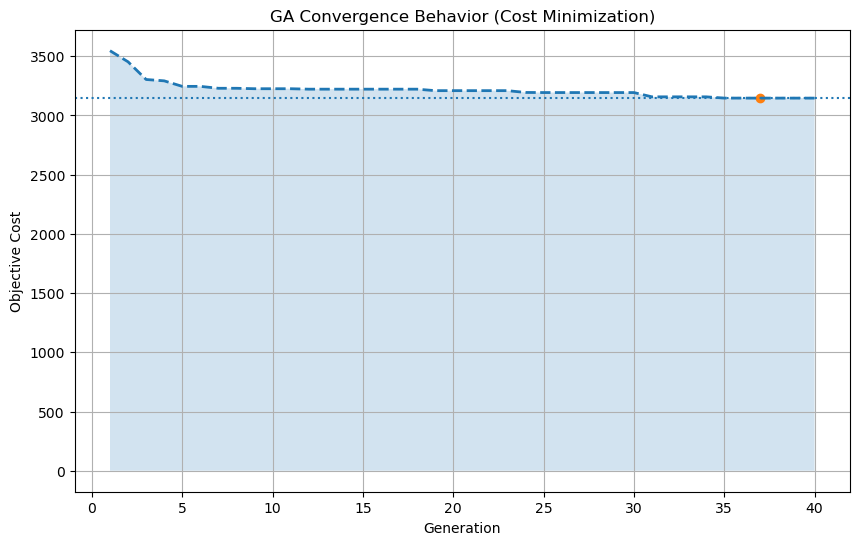

In [24]:
import matplotlib.pyplot as plt

generations = list(range(1, len(best_values)+1))

plt.figure(figsize=(10,6))

# Smooth style line
plt.plot(generations, best_values, linewidth=2, linestyle='--')

# Fill area under curve (this makes it UNIQUE)
plt.fill_between(generations, best_values, alpha=0.2)

# Best point
best_val = min(best_values)
best_gen = best_values.index(best_val) + 1

plt.scatter(best_gen, best_val)

# Horizontal line showing best cost
plt.axhline(y=best_val, linestyle=':')

# Labels
plt.title("GA Convergence Behavior (Cost Minimization)")
plt.xlabel("Generation")
plt.ylabel("Objective Cost")

plt.grid(True)

plt.show()

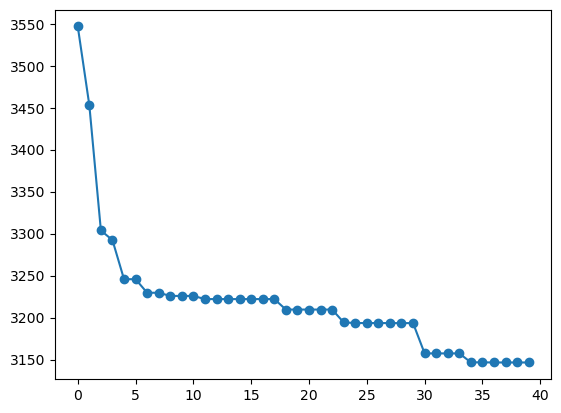

In [27]:
plt.plot(best_values, marker='o')

This graph shows how the genetic algorithm improves the solution over generations. Initially, the cost is high, but gradually it decreases and converges to an optimal value. The highlighted point represents the best solution found by the algorithm.